<a href="https://www.kaggle.com/code/swmath/modelo-summit?scriptVersionId=351427395" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Importação do dataset 

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_path = 'happydata.csv'

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "priyanshusethi/happiness-classification-dataset",
  file_path)

In [3]:
df.rename(columns={'infoavail': 'Disponibilidade de informação', 
                   'housecost': 'Custo da moradia',
                  'schoolquality' : 'Qualidade de ensino',
                  'policetrust' : 'Confiança na polícia',
                  'streetquality' : 'Qualidade das vias',
                  'ëvents' : 'Eventos públicos',
                  'happy': 'Felicidade'}, inplace=True)

,Disponibilidade de informação,Custo da moradia,Qualidade de ensino,Confiança na polícia,Qualidade das vias,Eventos públicos,Felicidade
0,3,3,3,4,2,4,0
1,3,2,3,5,4,3,0
2,5,3,3,3,3,5,1
3,5,4,3,3,3,5,0
4,5,4,3,3,3,5,0



Valores nulos por coluna:
Disponibilidade de informação    0
Custo da moradia                 0
Qualidade de ensino              0
Confiança na polícia             0
Qualidade das vias               0
Eventos públicos                 0
Felicidade                       0
dtype: int64


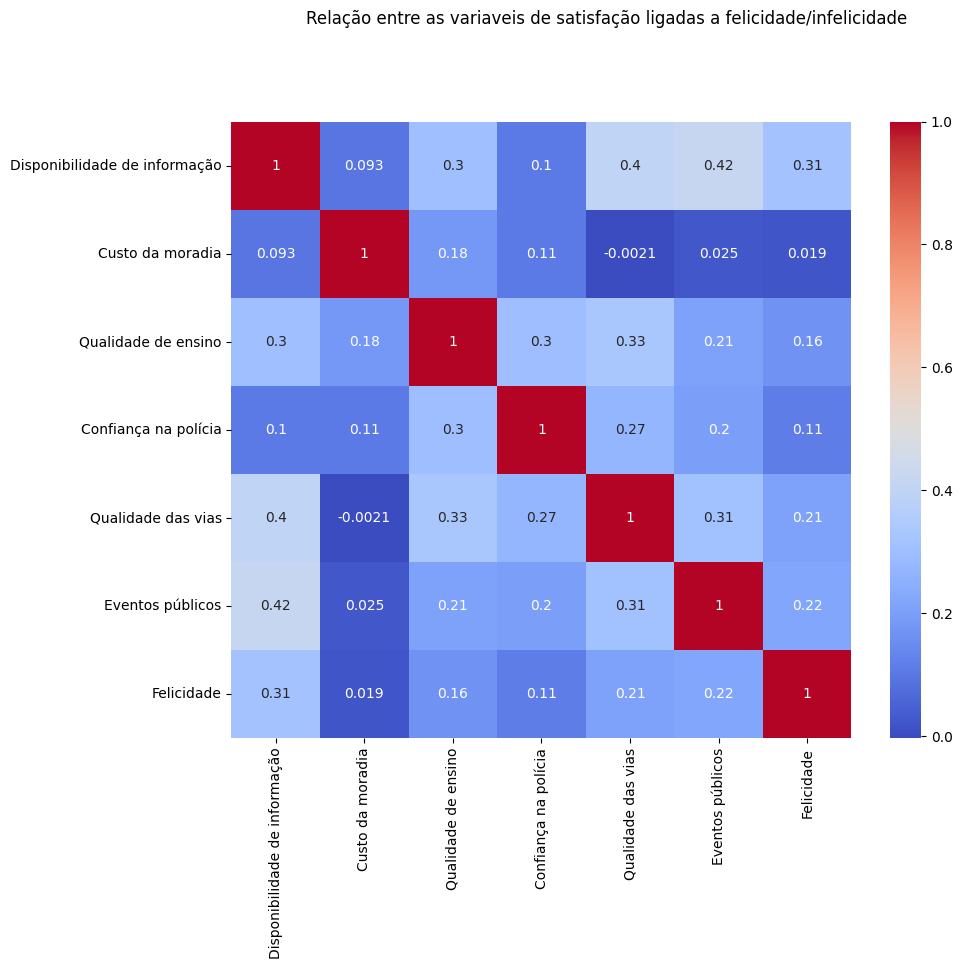

In [4]:
#Mostra as primeiras linhas da tabela
display(df.head())


# Verificação de valores nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

#Visualização principal: Relação entre as variáveis
#O pairplot cria gráficos de dispersão para todas as combinações de features
plt.figure(figsize=(10, 8))
#sns.pairplot(df, hue='happy', markers=["o", "s"])
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.suptitle("Relação entre as variaveis de satisfação ligadas a felicidade/infelicidade", y=1.02)
plt.show()

# Treinamento do modelo

In [5]:
# Bibliotecas para Machine Learning
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [13]:
# Features
colunas_uteis = ['Disponibilidade de informação', 'Eventos públicos', 'Qualidade das vias', 'Qualidade de ensino']
df['Score_Otimizado'] = df[colunas_uteis].sum(axis=1)

X = df.drop(columns = ['Felicidade', 'Custo da moradia', 'Confiança na polícia'])
y = df['Felicidade']  # Os rótulos (labels)

# Dividindo em treino (75%) e teste (25%)
# O stratify=y garante que a proporção dos resultados(feliz ou não) seja igual no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)



In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42)) 
])

# Dicionário de hiperparâmetros
# C: Controla o balanço entre ter uma margem suave ou penalizar severamente cada erro
# kernel: Define o formato matemático da linha de separação
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto'] # Otimiza o formato da curva no kernel rbf
}

# Configurar a busca pelos melhores parâmetros
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid = param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


# Treinamento do modelo (o scaler será ajustado corretamente em cada validação)
grid_search.fit(X_train, y_train)

# Resultados do treino 
print(f"Melhor acurácia obtida no treino: {grid_search.best_score_ * 100:.2f}%")
print(f"Melhores parâmetros: {grid_search.best_params_}")


# O best_estimator_ pega o melhor resultado vindo do treinamento do modelo
model = grid_search.best_estimator_

# Previsão no conjunto de teste
y_pred = model.predict(X_test)



Melhor acurácia obtida no treino: 65.28%
Melhores parâmetros: {'svc__C': 100, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}


# Resultado

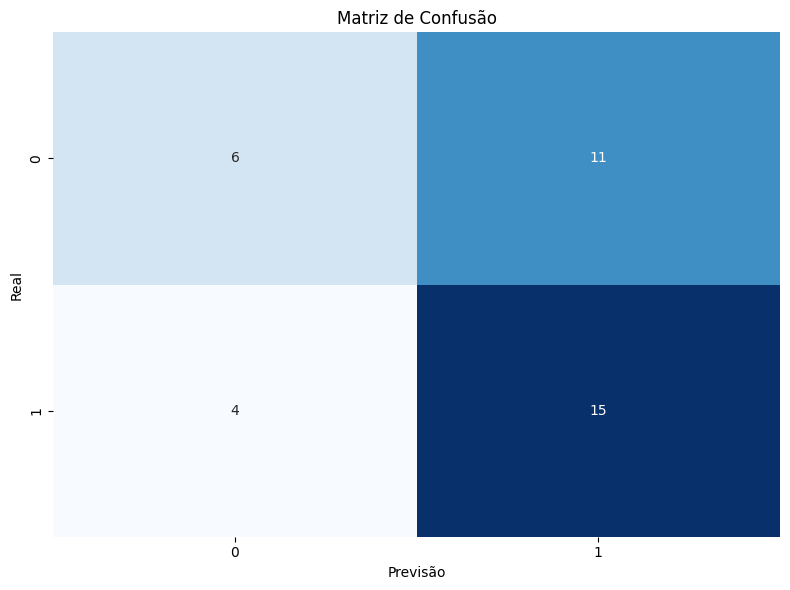

In [17]:
cm = confusion_matrix(y_test, y_pred)

# Faz um gráfico Heatmap baseado na matriz 'cm'
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')

# Ajusta as bordas
plt.tight_layout()

plt.savefig('matriz_de_confusao.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

/tmp/ipykernel_191/3826204104.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Atributo', data=df_pesos, palette='viridis')


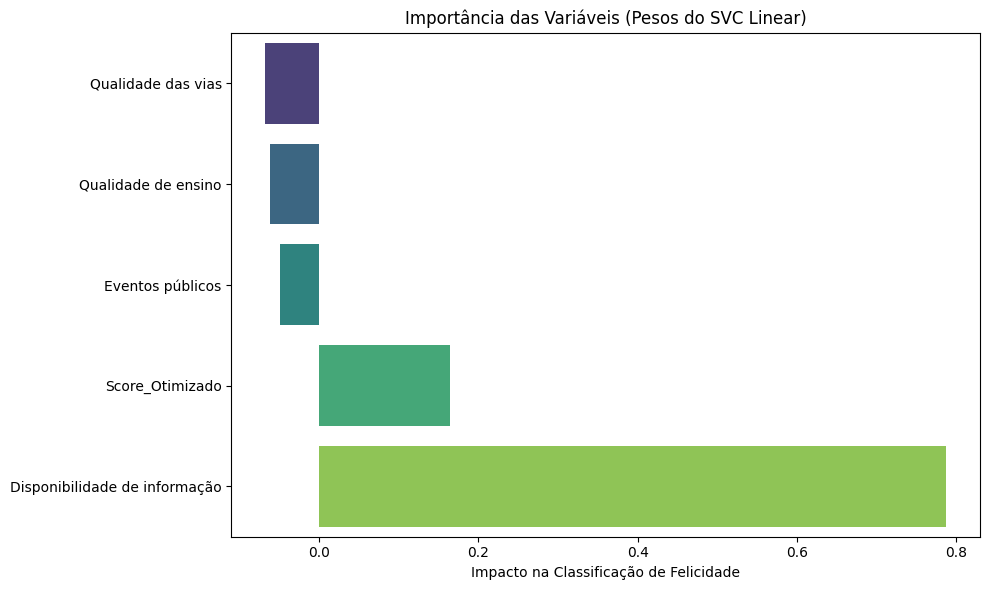

Sucesso: Os arquivos 'matriz_de_confusao.pdf' e 'pesos_dos_parametros.pdf' foram salvos na pasta atual.


In [18]:
svc_model = model.named_steps['svc']

# Só podemos extrair pesos lineares se o kernel for 'linear'
if svc_model.kernel == 'linear':
    # Extrai os pesos (coeficientes)
    pesos = svc_model.coef_[0]
    
    # Pega os nomes das colunas da variável X que você usou no treino
    nomes_features = X.columns 
    
    # Monta um DataFrame para facilitar a ordenação e o gráfico
    df_pesos = pd.DataFrame({'Atributo': nomes_features, 'Peso': pesos})
    df_pesos = df_pesos.sort_values(by='Peso', ascending=True)

    # Cria o gráfico de barras horizontais
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Peso', y='Atributo', data=df_pesos, palette='viridis')
    plt.title('Importância das Variáveis (Pesos do SVC Linear)')
    plt.xlabel('Impacto na Classificação de Felicidade')
    plt.ylabel('')
    
    plt.tight_layout()
    
    # Salva o arquivo localmente
    plt.savefig('pesos_dos_parametros.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show() # Exibe na tela (opcional)
    plt.close()
    
    print("Sucesso: Os arquivos 'matriz_de_confusao.pdf' e 'pesos_dos_parametros.pdf' foram salvos na pasta atual.")
else:
    print("Aviso: O kernel escolhido pelo GridSearch não foi 'linear'. Não é possível gerar o gráfico de pesos.")

In [16]:
df_comparacao = pd.DataFrame({
    'Predito': y_pred,
    'Real': y_test.values  # .values remove o índice para evitar desalinhamento
}, index=y_test.index)

print(df_comparacao)

     Predito  Real
110        1     1
75         0     1
61         1     1
119        1     0
125        1     0
25         0     1
108        0     1
96         1     0
5          1     1
63         1     1
130        1     0
45         1     0
37         1     0
10         0     0
38         1     1
88         0     0
117        1     0
84         1     1
22         0     0
134        1     1
80         1     0
127        0     0
124        1     1
85         1     0
17         1     1
95         1     1
56         1     1
89         0     1
43         1     0
121        0     0
32         1     0
62         1     1
14         0     0
12         1     1
137        1     1
30         1     1
